In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv("C:/Users/AU TRADERS/Downloads/datasets/Mcdonals dataset/MCD data set/mcdonalds_dataset.csv")
print(df)
print(df.head())
print (df.shape)


     Unnamed: 0                                    url_for_product  \
0             0   https://mcdonalds-menu.co.uk/bacon-mayo-chicken/   
1             1         https://mcdonalds-menu.co.uk/mayo-chicken/   
2             2            https://mcdonalds-menu.co.uk/hamburger/   
3             3                https://mcdonalds-menu.co.uk/fries/   
4             4         https://mcdonalds-menu.co.uk/cheeseburger/   
..          ...                                                ...   
147         147      https://mcdonalds-menu.co.uk/muffin-with-jam/   
148         148           https://mcdonalds-menu.co.uk/hash-brown/   
149         149       https://mcdonalds-menu.co.uk/pancakes-syrup/   
150         150  https://mcdonalds-menu.co.uk/pancakes-sausage-...   
151         151             https://mcdonalds-menu.co.uk/porridge/   

                      product_name  product_availability product_calories  \
0               Bacon Mayo Chicken                     1        kcal: 332   
1    

In [20]:
print(df.columns)
print(df.info())

Index(['Unnamed: 0', 'url_for_product', 'product_name', 'product_availability',
       'product_calories', 'product_price', 'have_sizes', 'Protein', 'Carbs',
       'Fat', 'Salt', 'Saturates', 'Sugars'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            152 non-null    int64  
 1   url_for_product       134 non-null    object 
 2   product_name          152 non-null    object 
 3   product_availability  152 non-null    int64  
 4   product_calories      152 non-null    object 
 5   product_price         152 non-null    object 
 6   have_sizes            152 non-null    int64  
 7   Protein               132 non-null    float64
 8   Carbs                 133 non-null    float64
 9   Fat                   133 non-null    float64
 10  Salt                  132 non-null    float64
 11  S

In [21]:
df = df.drop(columns=["Unnamed: 0"])

In [22]:
print( df.isna().sum())
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

url_for_product         18
product_name             0
product_availability     0
product_calories         0
product_price            0
have_sizes               0
Protein                 20
Carbs                   19
Fat                     19
Salt                    20
Saturates               20
Sugars                  23
dtype: int64
url_for_product         11.842105
product_name             0.000000
product_availability     0.000000
product_calories         0.000000
product_price            0.000000
have_sizes               0.000000
Protein                 13.157895
Carbs                   12.500000
Fat                     12.500000
Salt                    13.157895
Saturates               13.157895
Sugars                  15.131579
dtype: float64


In [23]:
print(df["product_calories"].unique())
print(df["product_price"].unique())

['kcal: 332' 'kcal: 285' 'kcal: 251' 'kcal: 237' 'kcal: 298' 'kcal: 438'
 'kcal: 495' 'kcal: 578' 'kcal: 643' 'kcal: 493' 'kcal: 437' 'kcal: 484'
 'kcal: 429' 'kcal: 590' 'kcal: 507' 'kcal: 739' 'kcal: 319' 'kcal: 369'
 'kcal: 361' 'kcal: 799' 'kcal: 845' 'kcal: 515' 'kcal: 519' 'kcal: 529'
 'kcal: 672' 'kcal: 581' 'kcal: 641' 'kcal: 648' 'kcal: 638' 'kcal: 693'
 'kcal: 694' 'kcal: 740' 'kcal: 231' 'kcal: 261' 'kcal: 869' 'kcal: 359'
 'kcal: 321' 'kcal: 12' 'kcal: 17' 'kcal: 256' 'kcal: 211' 'kcal: 769'
 'kcal: 210' 'kcal: 243' 'kcal: 365' 'kcal: 18' 'kcal: 195' 'kcal: 250'
 'kcal: 316' 'kcal: 320' 'kcal: 258' 'kcal: 273' 'kcal: 266' 'kcal: 532'
 'kcal: 403' 'kcal: 481' 'kcal: 366' 'kcal: 469' 'kcal: 432' 'kcal: 238'
 'kcal: 174' 'kcal: 197' 'kcal: 151' 'kcal: 265' 'kcal: 315' 'kcal: 133'
 'kcal: 183' 'kcal: 84' 'kcal: 89' 'kcal: 140' 'kcal: 290' 'kcal: 302'
 'kcal: 419' 'kcal: 356' 'kcal: 178' 'kcal: 192' 'kcal: 188' 'kcal: 201'
 'kcal: 184' 'kcal: 54' 'kcal: 6' 'kcal: 150' 'kcal: 145

In [24]:
df ["product_calories"] =(df["product_calories"].astype (str).str.replace("kcal:","",regex = False).str.strip())

In [25]:
df["product_calories"]= pd.to_numeric(df["product_calories"],errors="coerce")

In [26]:
df_clean = df.dropna(subset=["product_calories", "Fat"])
df_clean = df.dropna(subset=["product_calories","Fat"])


In [27]:
print(df_clean[["product_calories","Fat"]].head())
print(df_clean[["product_calories","Fat"]].isnull().sum())

   product_calories   Fat
0               332  12.0
1               285   9.1
2               251   8.3
3               237  12.0
4               298  12.0
product_calories    0
Fat                 0
dtype: int64


In [65]:
low_calories_products = df.sort_values(by="product_calories",ascending=True)
print(low_calories_products[["product_name","product_calories"]].head(10))

                product_name  product_calories
0         Bacon Mayo Chicken               NaN
1               Mayo Chicken               NaN
2                  Hamburger               NaN
3                      Fries               NaN
4               Cheeseburger               NaN
5        Double Cheeseburger               NaN
6  Bacon Double Cheeseburger               NaN
7        Triple Cheeseburger               NaN
8        Philly Cheese Stack               NaN
9                    Big Mac               NaN


In [66]:
nutrition_colums = ["Protein","Carbs","Fat","Salt","Saturates","Sugars"]
average_nutritioin = df[nutrition_colums].mean()
print(average_nutritioin)

Protein      17.400000
Carbs        36.037594
Fat          15.811278
Salt          1.371515
Saturates     5.649242
Sugars       11.836434
dtype: float64


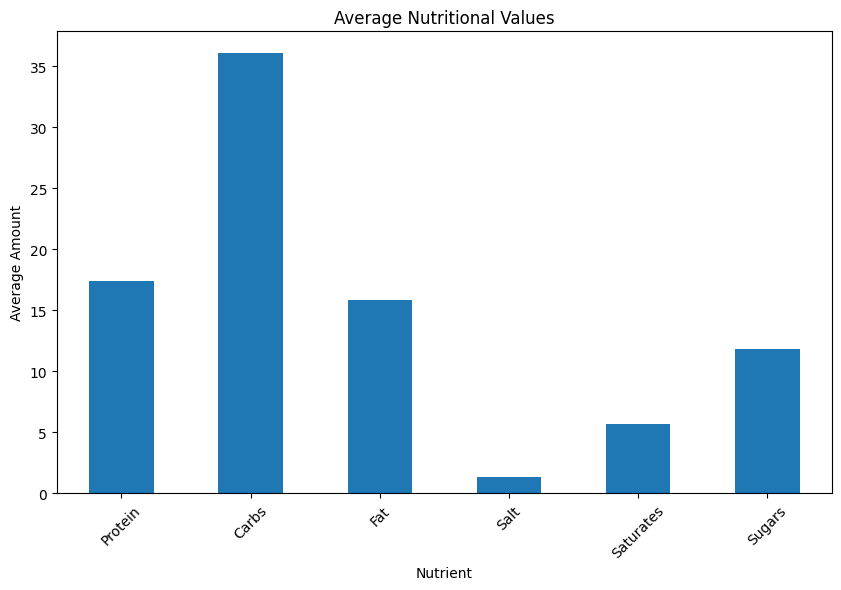

In [67]:

average_nutritioin.plot(kind = "bar",figsize= (10,6))
plt.title("Average Nutritional Values")
plt.xlabel("Nutrient")
plt.ylabel("Average Amount")
plt.xticks(rotation = 45)
plt.show()

In [70]:
correlation = df[["product_calories","Protein","Carbs","Fat","Salt","Saturates","Sugars"]].corr()
print(correlation)

                  product_calories   Protein     Carbs       Fat      Salt  \
product_calories               NaN       NaN       NaN       NaN       NaN   
Protein                        NaN  1.000000  0.313867  0.837270  0.901336   
Carbs                          NaN  0.313867  1.000000  0.354480  0.389850   
Fat                            NaN  0.837270  0.354480  1.000000  0.815175   
Salt                           NaN  0.901336  0.389850  0.815175  1.000000   
Saturates                      NaN  0.648905  0.184139  0.840712  0.654412   
Sugars                         NaN -0.323992  0.378723 -0.180074 -0.346122   

                  Saturates    Sugars  
product_calories        NaN       NaN  
Protein            0.648905 -0.323992  
Carbs              0.184139  0.378723  
Fat                0.840712 -0.180074  
Salt               0.654412 -0.346122  
Saturates          1.000000  0.086035  
Sugars             0.086035  1.000000  


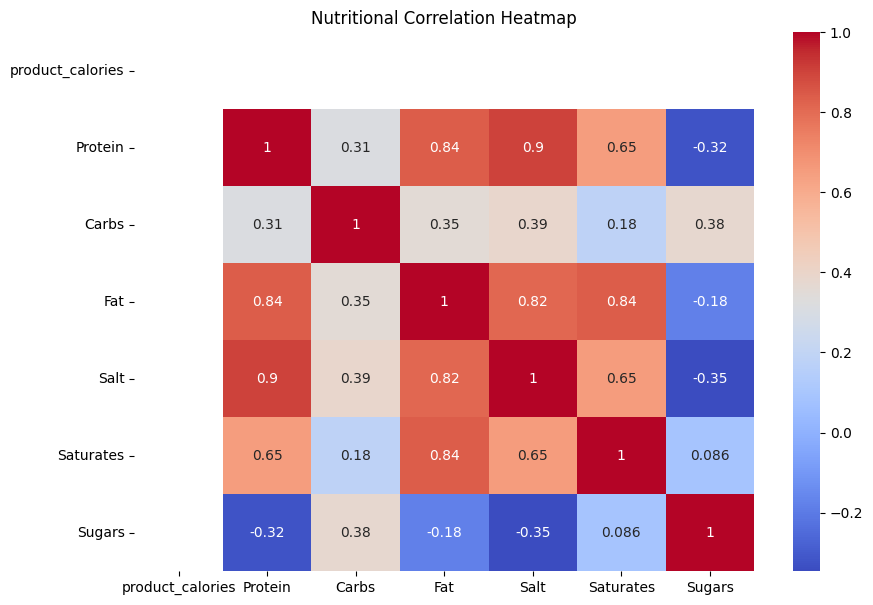

In [60]:
plt.figure(figsize=(10,7))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Nutritional Correlation Heatmap")
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/AU TRADERS/Downloads/datasets/Mcdonals dataset/MCD data set/mcdonalds_dataset.csv")

print(df["product_calories"].head())
print(df["product_calories"].dtype)

0    kcal: 332
1    kcal: 285
2    kcal: 251
3    kcal: 237
4    kcal: 298
Name: product_calories, dtype: object
object


In [3]:
df["product_calories"] = (
    df["product_calories"]
    .str.replace("kcal:", "", regex=False)
    .str.strip()
    .astype(int)
)

In [4]:
print(df["product_calories"].head())
print(df["product_calories"].dtype)

0    332
1    285
2    251
3    237
4    298
Name: product_calories, dtype: int32
int32


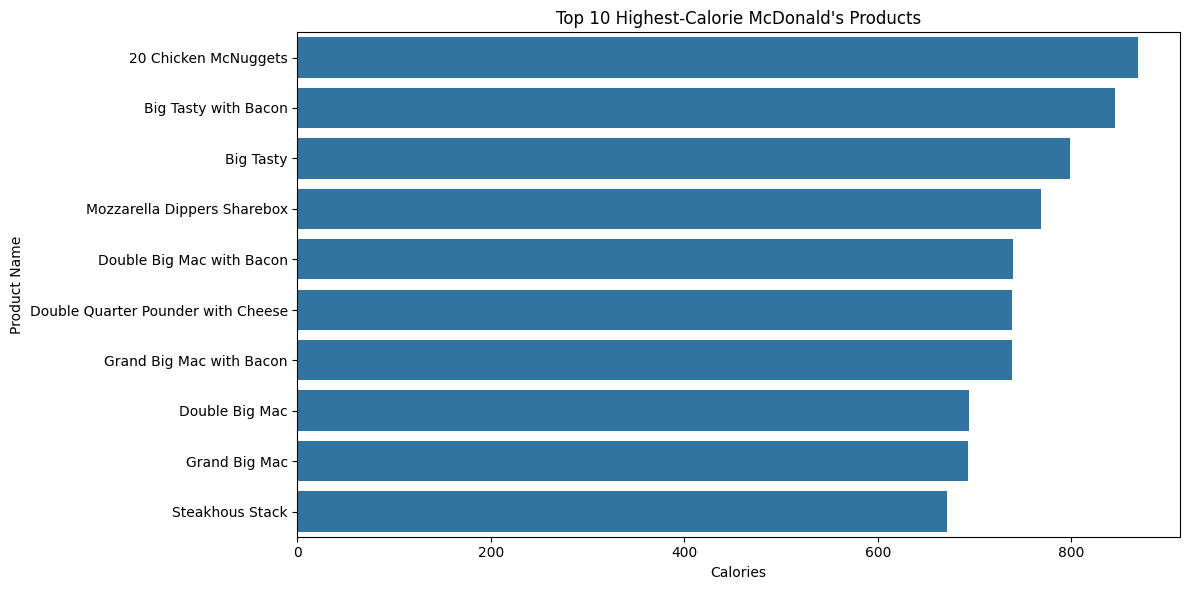

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/AU TRADERS/Downloads/datasets/Mcdonals dataset/MCD data set/mcdonalds_dataset.csv")

# Convert calories from "kcal: 332" to 332
df["product_calories"] = (
    df["product_calories"]
    .str.replace("kcal:", "", regex=False)
    .str.strip()
    .astype(int)
)

# Top 10 highest-calorie products
top_10_calories = df.nlargest(
    10,
    "product_calories"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_calories,
    x="product_calories",
    y="product_name"
)

plt.title("Top 10 Highest-Calorie McDonald's Products")
plt.xlabel("Calories")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

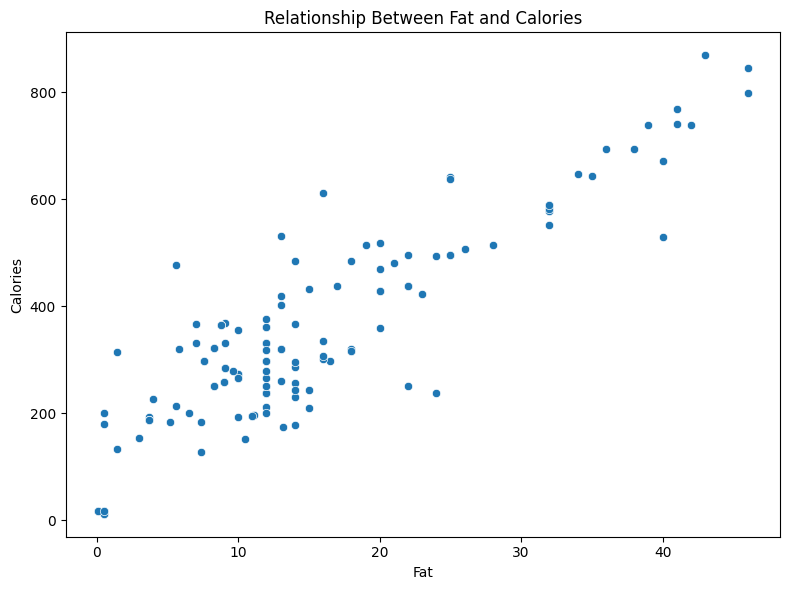

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Fat",
    y="product_calories"
)

plt.title("Relationship Between Fat and Calories")
plt.xlabel("Fat")
plt.ylabel("Calories")

plt.tight_layout()
plt.show()